# Model Training and Evaluation Pipeline

This notebook stitches together our modular `src/` scripts to perform end-to-end processing, feature engineering, and model training for the Appliance Energy Prediction assessment.

In [9]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add the src directory to our Python path so we can import our modules
sys.path.append(os.path.abspath('../src'))

from data_preprocessing import load_data, handle_missing_values, treat_outliers, scale_data, split_time_series
from feature_engineering import create_time_features, create_rolling_features, create_lagged_features, create_interaction_features, feature_selection
from model import get_baseline_model, build_lstm_model
from train import create_sequences, calculate_metrics, train_deep_model

sns.set_style('whitegrid')

## 1. Data Preprocessing & Feature Engineering

In [10]:
# 1. Load the data
df = load_data('../data/raw/energy_data_set.csv')
print(f"Original shape: {df.shape}")

# 2. Preprocessing
df = handle_missing_values(df)
df = treat_outliers(df, columns=['Appliances'])
print("Finished basic preprocessing.")

# 3. Feature Engineering
df = create_time_features(df)
df = create_rolling_features(df, target_col='Appliances')
df = create_lagged_features(df, target_col='Appliances')
df = create_interaction_features(df)
df = feature_selection(df) # Rembember: this drops the initial NaNs created by rolling/lagging!

print(f"Shape after feature engineering: {df.shape}")
display(df.head())

Original shape: (19735, 28)
Finished basic preprocessing.
Shape after feature engineering: (19717, 38)


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,month,is_weekend,Appliances_roll_mean_6,Appliances_roll_std_6,Appliances_roll_mean_18,Appliances_roll_std_18,Appliances_lag_1,Appliances_lag_3,Appliances_lag_6,Temp_diff_indoor_outdoor
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 20:00:00,80.0,30,20.890000,51.193333,20.20,46.330000,20.200000,48.193333,18.963333,48.630000,...,1,0,173.333333,141.515606,134.811111,148.053035,70.0,100.0,430.0,14.890000
2016-01-11 20:10:00,140.0,40,20.890000,49.800000,20.20,46.026667,20.166667,47.633333,19.033333,49.500000,...,1,0,115.000000,67.156534,135.922222,147.532698,80.0,90.0,250.0,14.890000
2016-01-11 20:20:00,120.0,20,20.890000,48.433333,20.20,45.722500,20.166667,47.300000,19.175000,49.947500,...,1,0,96.666667,24.221203,140.366667,146.310938,140.0,70.0,100.0,14.890000
2016-01-11 20:30:00,190.0,40,20.963333,47.633333,20.26,45.530000,20.200000,47.026667,19.260000,49.696667,...,1,0,100.000000,26.076810,144.255556,144.689035,120.0,80.0,100.0,14.963333
2016-01-11 20:40:00,110.0,40,21.033333,47.063333,20.29,45.223333,20.260000,46.826667,19.323333,49.166667,...,1,0,115.000000,45.055521,152.033333,143.078165,190.0,140.0,90.0,15.033333


## 2. Train/Test Split & Scaling

In [11]:
# 4. Split sequentially to prevent data leakage
train_df, test_df = split_time_series(df, train_ratio=0.8)

# 5. Scale the data (fitting ONLY on the train set to prevent leakage)
train_scaled, test_scaled, scaler = scale_data(train_df, test_df)

print(f"Training set shape: {train_scaled.shape}")
print(f"Testing set shape: {test_scaled.shape}")

Training set shape: (15773, 38)
Testing set shape: (3944, 38)


## 3. Sequence Generation for LSTM
We must reshape the 2D tabular data into 3D chunks `(samples, time_steps, features)` to feed into the LSTM.

In [12]:
# We need the integer index of our target variable ('Appliances')
target_idx = train_scaled.columns.get_loc('Appliances')
TIME_STEPS = 6 # Look back 1 hour (6 * 10 mins)

X_train, y_train = create_sequences(train_scaled.values, target_col_index=target_idx, time_steps=TIME_STEPS)
X_test, y_test = create_sequences(test_scaled.values, target_col_index=target_idx, time_steps=TIME_STEPS)

print(f"3D X_train shape: {X_train.shape}")
print(f"1D y_train shape: {y_train.shape}")

3D X_train shape: (15767, 6, 38)
1D y_train shape: (15767,)


## 4. Train the Baseline model (Random Forest)
We need a baseline mathematical score to see if our Deep Learning is actually helping.

In [13]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest cannot take 3D data, so we must flatten the sequences back to 2D
X_train_rf = X_train.reshape((X_train.shape[0], X_train.shape[1] * X_train.shape[2]))
X_test_rf = X_test.reshape((X_test.shape[0], X_test.shape[1] * X_test.shape[2]))

rf_model = get_baseline_model('rf')
print("Training Baseline Random Forest...")
rf_model.fit(X_train_rf, y_train)

# Evaluate
rf_predictions = rf_model.predict(X_test_rf)
rf_metrics = calculate_metrics(y_test, rf_predictions)
print(f"Baseline RF Metrics: {rf_metrics}")

Training Baseline Random Forest...
Baseline RF Metrics: {'MAE': 0.12271711528694783, 'RMSE': np.float64(0.17598684021660949), 'MAPE': np.float64(95.62131311053427)}


## 5. Train the LSTM Deep Learning Model

In [14]:
# Build architecture dynamically based on actual input shape
input_shape = (X_train.shape[1], X_train.shape[2])
lstm_model = build_lstm_model(input_shape=input_shape)

lstm_model.summary()

# Train with Early Stopping
history = train_deep_model(lstm_model, X_train, y_train, X_test, y_test, epochs=30, batch_size=64)

# Evaluate
lstm_predictions = lstm_model.predict(X_test)
# Flatten predictions for metric calculation
lstm_metrics = calculate_metrics(y_test, lstm_predictions.flatten())
print(f"LSTM Metrics: {lstm_metrics}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 6, 64)          │        26,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,329 (153.63 KB)

 Trainable params: 39,329 (153.63 KB)

 Non-trainable params: 0 (0.00 B)

...

247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0144 - mae: 0.0641 - val_loss: 0.0109 - val_mae: 0.0469
Epoch 4/30
246/247 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0132 - mae: 0.0594

247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0134 - mae: 0.0596 - val_loss: 0.0104 - val_mae: 0.0444
Epoch 5/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0130 - mae: 0.0585 - val_loss: 0.0115 - val_mae: 0.0516
Epoch 6/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0122 - mae: 0.0558

247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0127 - mae: 0.0566 - val_loss: 0.0101 - val_mae: 0.0477
Epoch 7/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0126 - mae: 0.0563 - val_loss: 0.0101 - val_mae: 0.0455
Epoch 8/30
243/247 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0124 - mae: 0.0553

247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0124 - mae: 0.0558 - val_loss: 0.0100 - val_mae: 0.0436
Epoch 9/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0125 - mae: 0.0560 - val_loss: 0.0103 - val_mae: 0.0445
Epoch 10/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0122 - mae: 0.0548 - val_loss: 0.0100 - val_mae: 0.0489
Epoch 11/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0123 - mae: 0.0552

247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0121 - mae: 0.0547 - val_loss: 0.0098 - val_mae: 0.0439
Epoch 12/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0121 - mae: 0.0549 - val_loss: 0.0102 - val_mae: 0.0450
Epoch 13/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0121 - mae: 0.0553 - val_loss: 0.0099 - val_mae: 0.0461
Epoch 14/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0120 - mae: 0.0542 - val_loss: 0.0101 - val_mae: 0.0508
Epoch 15/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0120 - mae: 0.0548 - val_loss: 0.0105 - val_mae: 0.0505
Epoch 16/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0118 - mae: 0.0540 - val_loss: 0.0103 - val_mae: 0.0488
Epoch 17/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0118 - mae: 0.0541 - val_loss: 0.0100 - val_mae: 0.0466
Epoch 18/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0117 - mae: 0.0538 - val_loss: 0.0102 - val_mae: 0.0505
Epoch 19/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - lo

## 6. Visualization of Results

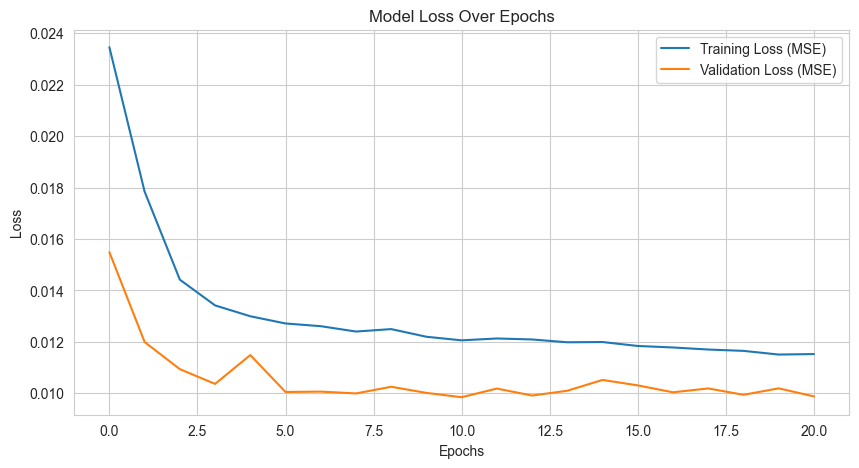

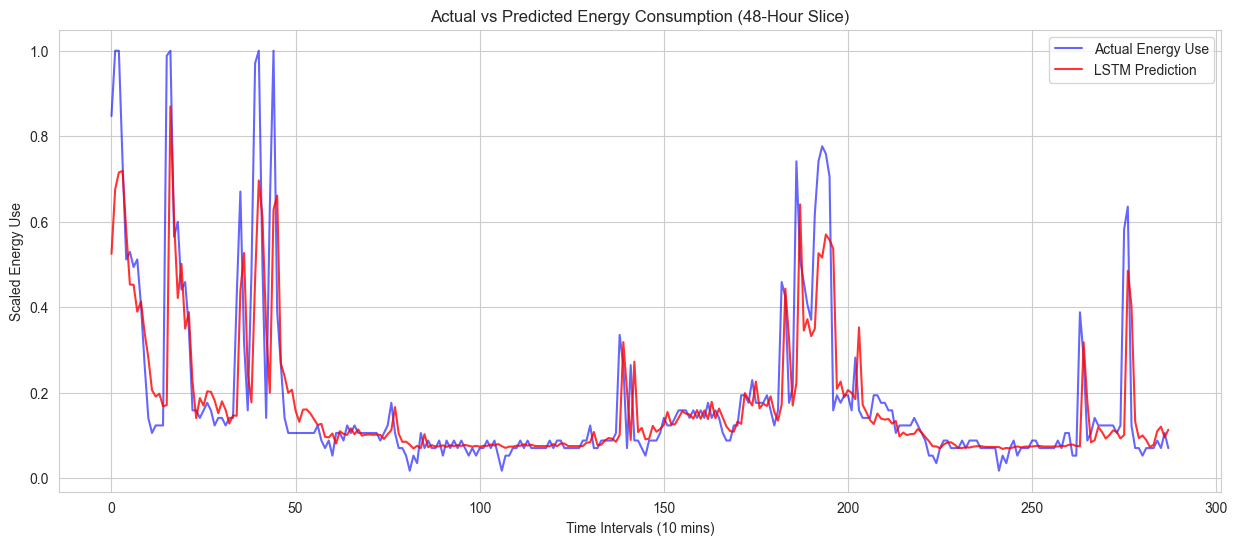

In [15]:
# Plot the training loss vs validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot a 2-day slice of actual vs predicted (to visualize fit)
# 1 day = 144 intervals (10-mins)
slice_size = 144 * 2 

plt.figure(figsize=(15, 6))
plt.plot(y_test[:slice_size], label='Actual Energy Use', color='blue', alpha=0.6)
plt.plot(lstm_predictions.flatten()[:slice_size], label='LSTM Prediction', color='red', alpha=0.8)
plt.title('Actual vs Predicted Energy Consumption (48-Hour Slice)')
plt.xlabel('Time Intervals (10 mins)')
plt.ylabel('Scaled Energy Use')
plt.legend()
plt.show()